In [1]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# ==========================================
# IMAGE CLASSIFICATION (TRANSFER LEARNING)
# ==========================================

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Modern model import (no warnings)
from torchvision.models import vgg16, VGG16_Weights

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================
# TRANSFORM (IMPORTANT)
# ======================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ======================
# DATASET (CIFAR-10)
# ======================
dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)

# 🔥 Reduce dataset size for fast lab execution
subset_size = 500
indices = torch.randperm(len(dataset))[:subset_size]
dataset = torch.utils.data.Subset(dataset, indices)

loader = DataLoader(dataset, batch_size=16, shuffle=True)

# ======================
# MODEL (VGG16)
# ======================
model = vgg16(weights=VGG16_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace last layer
model.classifier[6] = nn.Linear(4096, 10)
model = model.to(device)

# ======================
# TRAINING
# ======================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)

print("Training started...")

for epoch in range(7):   # reduced for speed
    total_loss = 0
    model.train()
    
    for i, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        
        out = model(x)
        loss = criterion(out, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        if i % 20 == 0:
            print(f"Batch {i} running...")
    
    print("Epoch:", epoch+1, "Loss:", total_loss)

print("Training completed!")
torch.save(model.state_dict(), "cifar_model.pth")
print("Model saved!")


Training started...
Batch 0 running...
Batch 20 running...
Epoch: 1 Loss: 47.17360192537308
Batch 0 running...
Batch 20 running...
Epoch: 2 Loss: 21.2897527217865
Batch 0 running...
Batch 20 running...
Epoch: 3 Loss: 16.25057077407837
Batch 0 running...
Batch 20 running...
Epoch: 4 Loss: 12.8799879103899
Batch 0 running...
Batch 20 running...
Epoch: 5 Loss: 11.097039714455605
Batch 0 running...
Batch 20 running...
Epoch: 6 Loss: 9.432080261409283
Batch 0 running...
Batch 20 running...
Epoch: 7 Loss: 8.587846644222736
Training completed!
Model saved!


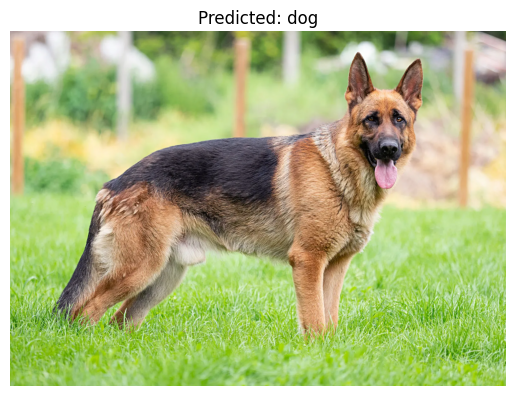

In [3]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.models import vgg16, VGG16_Weights

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load model
model = vgg16(weights=VGG16_Weights.DEFAULT)
model.classifier[6] = nn.Linear(4096, 10)
model.load_state_dict(torch.load("cifar_model.pth"))
model = model.to(device)
model.eval()

# CIFAR-10 class names (manual)
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

# Image path
img_path = r"Z:\German-Shepherd-dog-Alsatian.webp"

img = Image.open(img_path).convert("RGB")

inp = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    pred = torch.argmax(model(inp)).item()

label = classes[pred]

plt.imshow(img)
plt.title("Predicted: " + label)
plt.axis("off")
plt.show()